In [2]:
import BECancerResistome
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Load Data

In [160]:
#Ganna's z-scores
ht29_zscores_ganna = pd.read_excel("/Users/carolinapinto/desktop/Tese/Data/EG/Zscore_Combined_A375_HT29.xlsx", sheet_name='HT29')

#Our newly calculated z-scores
zscores = pd.read_csv("data/4_Screen_zscores/EG/EG_zscores.csv")

#Beagle-generated file EG
beagle = pd.read_csv("data/1_Beagle_design_files/EG/EG-guides.txt", sep="\t")

#LFCS
lfcs = pd.read_csv("data/5_LFC/EG/EG_LFC.csv")


In [9]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [140]:
zscores.columns.to_list()

['Guide',
 'Gene',
 'Editor',
 'A375_RDA270_CP2165_PIC_RepA',
 'A375_RDA270_CP2165_PIC_RepB',
 'A375_RDA270_CP2165_SCH_RepA',
 'A375_RDA270_CP2165_SCH_RepB',
 'A375_RDA270_CP2165_LIN_RepA',
 'A375_RDA270_CP2165_LIN_RepB',
 'HT29_RDA270_CP2165_PIC_RepA',
 'HT29_RDA270_CP2165_PIC_RepB',
 'HT29_RDA270_CP2165_SCH_RepA',
 'HT29_RDA270_CP2165_SCH_RepB',
 'HT29_RDA270_CP2165_LIN_RepA',
 'HT29_RDA270_CP2165_LIN_RepB']

In [141]:
#Filter z-scores to HT-29
columns_to_keep = [
    'Guide',
    'Gene',
    'Editor',
    'HT29_RDA270_CP2165_PIC_RepA',
    'HT29_RDA270_CP2165_PIC_RepB',
    'HT29_RDA270_CP2165_SCH_RepA',
    'HT29_RDA270_CP2165_SCH_RepB',
    'HT29_RDA270_CP2165_LIN_RepA',
    'HT29_RDA270_CP2165_LIN_RepB'
]

ht29_zscores = zscores[columns_to_keep]


In [142]:
#Filter to PIK3CA gene symbol
ht29_pik3ca_zscores = ht29_zscores[ht29_zscores['Gene'] == 'PIK3CA']

In [161]:
lfcs =lfcs[lfcs['Gene'] == 'PIK3CA']

In [143]:
ht29_pik3ca_zscores.columns.to_list()

['Guide',
 'Gene',
 'Editor',
 'HT29_RDA270_CP2165_PIC_RepA',
 'HT29_RDA270_CP2165_PIC_RepB',
 'HT29_RDA270_CP2165_SCH_RepA',
 'HT29_RDA270_CP2165_SCH_RepB',
 'HT29_RDA270_CP2165_LIN_RepA',
 'HT29_RDA270_CP2165_LIN_RepB']

In [144]:
#Add a column with absolute minimum z-score of RepA and RepB 
ht29_pik3ca_zscores=ht29_pik3ca_zscores.copy()

#PIC
ht29_pik3ca_zscores["HT29_RDA270_CP2165_PIC_RepAB"] = ht29_pik3ca_zscores[
    ["HT29_RDA270_CP2165_PIC_RepA", "HT29_RDA270_CP2165_PIC_RepB"]
].apply(lambda row: row.loc[row.abs().idxmin()], axis=1)

#SCH
ht29_pik3ca_zscores["HT29_RDA270_CP2165_SCH_RepAB"] = ht29_pik3ca_zscores[
    ["HT29_RDA270_CP2165_SCH_RepA", "HT29_RDA270_CP2165_SCH_RepB"]
].apply(lambda row: row.loc[row.abs().idxmin()], axis=1)

#LIN
ht29_pik3ca_zscores["HT29_RDA270_CP2165_LIN_RepAB"] = ht29_pik3ca_zscores[
    ["HT29_RDA270_CP2165_LIN_RepA", "HT29_RDA270_CP2165_LIN_RepB"]
].apply(lambda row: row.loc[row.abs().idxmin()], axis=1)


In [145]:
#Filter Beagle-generated file to PIK3CA gene symbol and C-T edit 
beagle_pik3ca = beagle[(beagle['Target Gene Symbol'] == 'PIK3CA') & (beagle['Edit Type'] == 'C-T')]

# Dataset Inspection

In [146]:
ht29_pik3ca_zscores.head()

,Guide,Gene,Editor,HT29_RDA270_CP2165_PIC_RepA,HT29_RDA270_CP2165_PIC_RepB,HT29_RDA270_CP2165_SCH_RepA,HT29_RDA270_CP2165_SCH_RepB,HT29_RDA270_CP2165_LIN_RepA,HT29_RDA270_CP2165_LIN_RepB,HT29_RDA270_CP2165_PIC_RepAB,HT29_RDA270_CP2165_SCH_RepAB,HT29_RDA270_CP2165_LIN_RepAB
7739,AAAACAGTTAGCCAGAGGTT,PIK3CA,CBE,0.946553,-0.293294,0.716058,-0.036592,0.274244,-0.775194,-0.293294,-0.036592,0.274244
7740,AAAACTGAGCAAGAGGCTTT,PIK3CA,CBE,-0.799917,-0.542635,-0.919411,0.437326,-0.758403,-0.045441,-0.542635,0.437326,-0.045441
7741,AAAATATCTGGCAAAATCAA,PIK3CA,CBE,-0.210904,-1.533908,-1.349748,-1.428223,0.125845,-0.571281,-0.210904,-1.349748,0.125845
7742,AAAATCAAGGTCTTGATCTT,PIK3CA,CBE,0.081093,-0.488784,-1.257467,-0.465367,-0.556130,0.007722,0.081093,-0.465367,0.007722
7743,AAAATCTTTCTCCTGCTCAG,PIK3CA,CBE,-1.725096,-1.173867,-0.090351,0.858353,0.954169,0.168413,-1.173867,-0.090351,0.168413


In [162]:
lfcs[lfcs['Guide']=='CTCCTGCTCAGTGATTTCAG']

,Guide,Gene,Editor,A375_RDA270_CP2165_PIC_RepA,A375_RDA270_CP2165_PIC_RepB,A375_RDA270_CP2165_SCH_RepA,A375_RDA270_CP2165_SCH_RepB,A375_RDA270_CP2165_LIN_RepA,A375_RDA270_CP2165_LIN_RepB,HT29_RDA270_CP2165_PIC_RepA,HT29_RDA270_CP2165_PIC_RepB,HT29_RDA270_CP2165_SCH_RepA,HT29_RDA270_CP2165_SCH_RepB,HT29_RDA270_CP2165_LIN_RepA,HT29_RDA270_CP2165_LIN_RepB
8078,CTCCTGCTCAGTGATTTCAG,PIK3CA,CBE,0.133302,-0.706253,1.213384,0.315502,2.270822,1.984421,-2.847386,-2.292415,0.868382,1.962531,4.709724,5.01279


In [167]:
ht29_pik3ca_zscores[ht29_pik3ca_zscores['Guide'] == 'CTCCTGCTCAGTGATTTCAG']

,Guide,Gene,Editor,HT29_RDA270_CP2165_PIC_RepA,HT29_RDA270_CP2165_PIC_RepB,HT29_RDA270_CP2165_SCH_RepA,HT29_RDA270_CP2165_SCH_RepB,HT29_RDA270_CP2165_LIN_RepA,HT29_RDA270_CP2165_LIN_RepB,HT29_RDA270_CP2165_PIC_RepAB,HT29_RDA270_CP2165_SCH_RepAB,HT29_RDA270_CP2165_LIN_RepAB
8078,CTCCTGCTCAGTGATTTCAG,PIK3CA,CBE,-12.545602,-10.484047,5.281426,6.152578,7.844169,8.261626,-10.484047,5.281426,7.844169


In [168]:
ht29_zscores_ganna[ht29_zscores_ganna['sgRNA Target Sequence']== 'CTCCTGCTCAGTGATTTCAG'][['HT29_RDA270_CP2165_PIC_RepB','HT29_RDA270_CP2165_PIC_RepA','HT29_RDA270_CP2165_PIC_RepA;z-score','HT29_RDA270_CP2165_PIC_RepB;z-score', 'HT29_RDA270_CP2165_PIC_RepAB']]

,HT29_RDA270_CP2165_PIC_RepB,HT29_RDA270_CP2165_PIC_RepA,HT29_RDA270_CP2165_PIC_RepA;z-score,HT29_RDA270_CP2165_PIC_RepB;z-score,HT29_RDA270_CP2165_PIC_RepAB
12262,-2.355882,-2.929759,-15.043584,-12.875346,-2.355882


In [166]:
ht29_zscores_ganna.columns.to_list()

['Subpool Name',
 'Target Taxon',
 'CRISPR Mechanism',
 'Target Gene ID',
 'Target Gene Symbol',
 'sgRNA Target Sequence',
 'Unnamed: 0',
 'Construct Barcode',
 'Construct IDs',
 'Unlabeled Sample Barcodes',
 'guide_seq',
 'Nothing',
 'Potential IDs',
 'Total',
 'pDNA_CP2165',
 'HT29_RDA270_CP2165_PIC_RepB',
 'HT29_RDA270_CP2165_PIC_RepA',
 'HT29_RDA270_CP2165_LIN_RepA',
 'HT29_RDA270_CP2165_LIN_RepB',
 'HT29_RDA270_CP2165_SCH_RepA',
 'HT29_RDA270_CP2165_SCH_RepB',
 'HT29_RDA270_CP2165_PIC_RepA;z-score',
 'HT29_RDA270_CP2165_PIC_RepB;z-score',
 'HT29_RDA270_CP2165_PIC_RepAB',
 'HT29_RDA270_CP2165_LIN_RepAB',
 'HT29_RDA270_CP2165_SCH_RepAB']

In [136]:
ht29_zscores_ganna[ht29_zscores_ganna['Target Gene Symbol']== 'PIK3CA'].head()

,Subpool Name,Target Taxon,CRISPR Mechanism,Target Gene ID,Target Gene Symbol,sgRNA Target Sequence,Unnamed: 0,Construct Barcode,Construct IDs,Unlabeled Sample Barcodes,guide_seq,Nothing,Potential IDs,Total,pDNA_CP2165,HT29_RDA270_CP2165_PIC_RepB,HT29_RDA270_CP2165_PIC_RepA,HT29_RDA270_CP2165_LIN_RepA,HT29_RDA270_CP2165_LIN_RepB,HT29_RDA270_CP2165_SCH_RepA,HT29_RDA270_CP2165_SCH_RepB,HT29_RDA270_CP2165_PIC_RepA;z-score,HT29_RDA270_CP2165_PIC_RepB;z-score,HT29_RDA270_CP2165_PIC_RepAB,HT29_RDA270_CP2165_LIN_RepAB,HT29_RDA270_CP2165_SCH_RepAB
12262,Goncalves,9606,CRISPRbe,ENSG00000121879,PIK3CA,CTCCTGCTCAGTGATTTCAG,8078,CTCCTGCTCAGTGATTTCAG,CATGTTGCCCTGAGGCACAGCGTCTCACACCGCTCCTGCTCAGTGA...,5,CTCCTGCTCAGTGATTTCAG,1.0,0.0,13143.0,5.609338,-2.355882,-2.929759,4.584749,4.897648,1.555033,1.847987,-15.043584,-12.875346,-2.355882,4.584749,1.555033
12263,Goncalves,9606,CRISPRbe,ENSG00000121879,PIK3CA,ATTCTTCCCTTTCTGCTTCT,7967,ATTCTTCCCTTTCTGCTTCT,CATGTTGCCCTGAGGCACAGCGTCTCACACCGATTCTTCCCTTTCT...,3,ATTCTTCCCTTTCTGCTTCT,1.0,0.0,1907.0,5.759229,-2.040379,-2.041634,4.994683,5.134618,1.455363,1.596325,-10.499914,-11.153738,-2.040379,4.994683,1.455363
12264,Goncalves,9606,CRISPRbe,ENSG00000121879,PIK3CA,CCTGCTCAGTGATTTCAGAG,8055,CCTGCTCAGTGATTTCAGAG,CATGTTGCCCTGAGGCACAGCGTCTCACACCGCCTGCTCAGTGATT...,2,CCTGCTCAGTGATTTCAGAG,10.0,0.0,133350.0,5.873074,-1.898816,-2.343990,5.191614,5.422724,2.009471,2.396120,-12.046774,-10.381267,-1.898816,5.191614,2.009471
12265,Goncalves,9606,CRISPRbe,ENSG00000121879,PIK3CA,TTCTCCTGCTCAGTGATTTC,8443,TTCTCCTGCTCAGTGATTTC,CATGTTGCCCTGAGGCACAGCGTCTCACACCGTTCTCCTGCTCAGT...,0,TTCTCCTGCTCAGTGATTTC,0.0,0.0,1523.0,5.298374,-1.815159,-1.734509,1.490387,2.327464,0.170511,0.240556,-8.928655,-9.924777,-1.734509,1.490387,0.170511
12266,Goncalves,9606,CRISPRbe,ENSG00000121879,PIK3CA,GCTCAGTGATTTCAGAGAGA,8185,GCTCAGTGATTTCAGAGAGA,CATGTTGCCCTGAGGCACAGCGTCTCACACCGGCTCAGTGATTTCA...,7,GCTCAGTGATTTCAGAGAGA,1.0,0.0,24629.0,5.794653,-1.725835,-1.929709,5.245085,5.466715,2.250612,2.447727,-9.927301,-9.437359,-1.725835,5.245085,2.250612


In [147]:
beagle_pik3ca.head()

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note
24565,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,CATTGTTCTGATTCTTTGCA,GAGGCATTGTTCTGATTCTTTGCAAGTTTT,AG,179198809,antisense,179198821G>A,C_8,-5G>A,(NC),UTR,NaN,NaN
24567,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,GAGGCATTGTTCTGATTCTT,CGTGGAGGCATTGTTCTGATTCTTTGCAAG,TG,179198813,antisense,179198828G>A,C_5,3G>A,Met1Ile,Missense,NaN,NaN
24569,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,TGGTCGTGGAGGCATTGTTC,ATGATGGTCGTGGAGGCATTGTTCTGATTC,TG,179198821,antisense,179198836G>A,C_5,11G>A,Arg4Gln,Missense,NaN,NaN
24571,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,ATGCCTCCACGACCATCATC,AACAATGCCTCCACGACCATCATCAGGTGA,AG,179198826,sense,"179198829C>T;179198830C>T, 179198832C>T;179198...","C_4;C_5, C_7;C_8","4C>T;5C>T, 7C>T;8C>T","Pro2Phe, Pro3Leu","Missense, Missense",NaN,NaN
24573,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,GATGATGGTCGTGGAGGCAT,ACCTGATGATGGTCGTGGAGGCATTGTTCT,TG,179198826,antisense,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [148]:
#Check duplicates
print("Duplicates in z-scores file:", ht29_pik3ca_zscores['Guide'].duplicated().sum())
print("Duplicates in Beagle library:", beagle_pik3ca['sgRNA Sequence'].duplicated().sum())

Duplicates in z-scores file: 0
Duplicates in Beagle library: 0


In [149]:
#Check mismatches between guides
not_in_beagle = ht29_pik3ca_zscores[~ht29_pik3ca_zscores['Guide'].isin(beagle_pik3ca['sgRNA Sequence'])]
not_in_zscores = beagle_pik3ca[~beagle_pik3ca['sgRNA Sequence'].isin(ht29_pik3ca_zscores['Guide'])]
print("Guides in z-scores file not in Beagle library:", len(not_in_beagle))
print("Guides in Beagle library not in z-scores file:", len(not_in_zscores))

Guides in z-scores file not in Beagle library: 0
Guides in Beagle library not in z-scores file: 5


# Processing

In [150]:
#Merge z-scores with Beagle library
ht29_pik3ca_merged = beagle_pik3ca.merge(ht29_pik3ca_zscores, left_on='sgRNA Sequence', right_on='Guide', how='inner')

In [183]:
ht29_pik3ca_merged.head()

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,Guide,Gene,Editor,HT29_RDA270_CP2165_PIC_RepA,HT29_RDA270_CP2165_PIC_RepB,HT29_RDA270_CP2165_SCH_RepA,HT29_RDA270_CP2165_SCH_RepB,HT29_RDA270_CP2165_LIN_RepA,HT29_RDA270_CP2165_LIN_RepB,HT29_RDA270_CP2165_PIC_RepAB,HT29_RDA270_CP2165_SCH_RepAB,HT29_RDA270_CP2165_LIN_RepAB,Residues,Median Residues
1,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,GAGGCATTGTTCTGATTCTT,CGTGGAGGCATTGTTCTGATTCTTTGCAAG,TG,179198813,antisense,179198828G>A,C_5,3G>A,Met1Ile,Missense,NaN,NaN,GAGGCATTGTTCTGATTCTT,PIK3CA,CBE,-0.071290,-0.402029,0.764870,-0.033912,0.269789,0.013401,-0.071290,-0.033912,0.013401,1;,1.0
3,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,ATGCCTCCACGACCATCATC,AACAATGCCTCCACGACCATCATCAGGTGA,AG,179198826,sense,"179198829C>T;179198830C>T, 179198832C>T;179198...","C_4;C_5, C_7;C_8","4C>T;5C>T, 7C>T;8C>T","Pro2Phe, Pro3Leu","Missense, Missense",NaN,NaN,ATGCCTCCACGACCATCATC,PIK3CA,CBE,-1.574557,-0.388821,1.315542,0.067647,3.996174,0.589616,-0.388821,0.067647,0.589616,2;3;,2.5
5,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,TGCCTCCACGACCATCATCA,ACAATGCCTCCACGACCATCATCAGGTGAA,GG,179198827,sense,"179198830C>T, 179198832C>T;179198833C>T","C_4, C_6;C_7","5C>T, 7C>T;8C>T","Pro2Leu, Pro3Leu","Missense, Missense",NaN,NaN,TGCCTCCACGACCATCATCA,PIK3CA,CBE,-1.817185,-0.904247,-1.207795,-0.178049,0.865405,2.099229,-0.904247,-0.178049,0.865405,2;3;,2.5
6,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,CCTCCACGACCATCATCAGG,AATGCCTCCACGACCATCATCAGGTGAACT,TG,179198829,sense,"179198832C>T;179198833C>T, 179198835C>T","C_4;C_5, C_7","7C>T;8C>T, 10C>T","Pro3Leu, Arg4Ter","Missense, Nonsense",NaN,NaN,CCTCCACGACCATCATCAGG,PIK3CA,CBE,0.584940,-0.746962,1.017254,-0.476387,0.613620,0.308039,0.584940,-0.476387,0.308039,3;4;,3.5
2,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,TGGTCGTGGAGGCATTGTTC,ATGATGGTCGTGGAGGCATTGTTCTGATTC,TG,179198821,antisense,179198836G>A,C_5,11G>A,Arg4Gln,Missense,NaN,NaN,TGGTCGTGGAGGCATTGTTC,PIK3CA,CBE,-0.970261,0.052052,-0.170818,-0.335356,0.003947,0.273907,0.052052,-0.170818,0.003947,4;,4.0


In [152]:
#From Ganna's analysis pipeline

#Fxn that gets amino acid residues to be plotted 
def GetResidues(string):
    new_string = ''
    if type(string) != float:
        edits = string.split(',')
        #split on comma for libraries designed with BEAGLE, split on semi-colon for libraries designed with Mudra's code
        for edit in edits:
            if edit.startswith('Exon'):
                new_string += 'intron;'
            elif edit == 'utr':
                new_string += 'utr;'
            elif edit == '':
                continue
            else:
                # Strip off all non-digit characters
                for character in edit:
                    if character.isdigit():        
                        new_string += character
                new_string += ';'
    return new_string

def GetMedianResidues(string):
    residues = string.split(';')
    if ('intron' in residues) or ('utr' in residues):
        return np.nan
    residues = [int(res) for res in residues if res != '']
    if len(residues) != 0:
        return np.median(residues)
    else:
        return np.nan

In [153]:
ht29_pik3ca_merged['Residues']=ht29_pik3ca_merged['Amino Acid Edits'].apply(GetResidues)
ht29_pik3ca_merged['Median Residues']=ht29_pik3ca_merged['Residues'].apply(GetMedianResidues)

In [175]:
ht29_pik3ca_540_600 = ht29_pik3ca_merged[(ht29_pik3ca_merged['Median Residues'] >= 76) & 
                                         (ht29_pik3ca_merged['Median Residues'] <= 600)]

In [ ]:
ht29_pik3ca_merged.sort_values(by='Median Residues', ascending=True, inplace=True)
ht29_pik3ca_merged[['sgRNA Sequence', 'Nucleotide Edits', 'Amino Acid Edits','Mutation Category','HT29_RDA270_CP2165_PIC_RepAB','HT29_RDA270_CP2165_LIN_RepAB', 'Median Residues']]

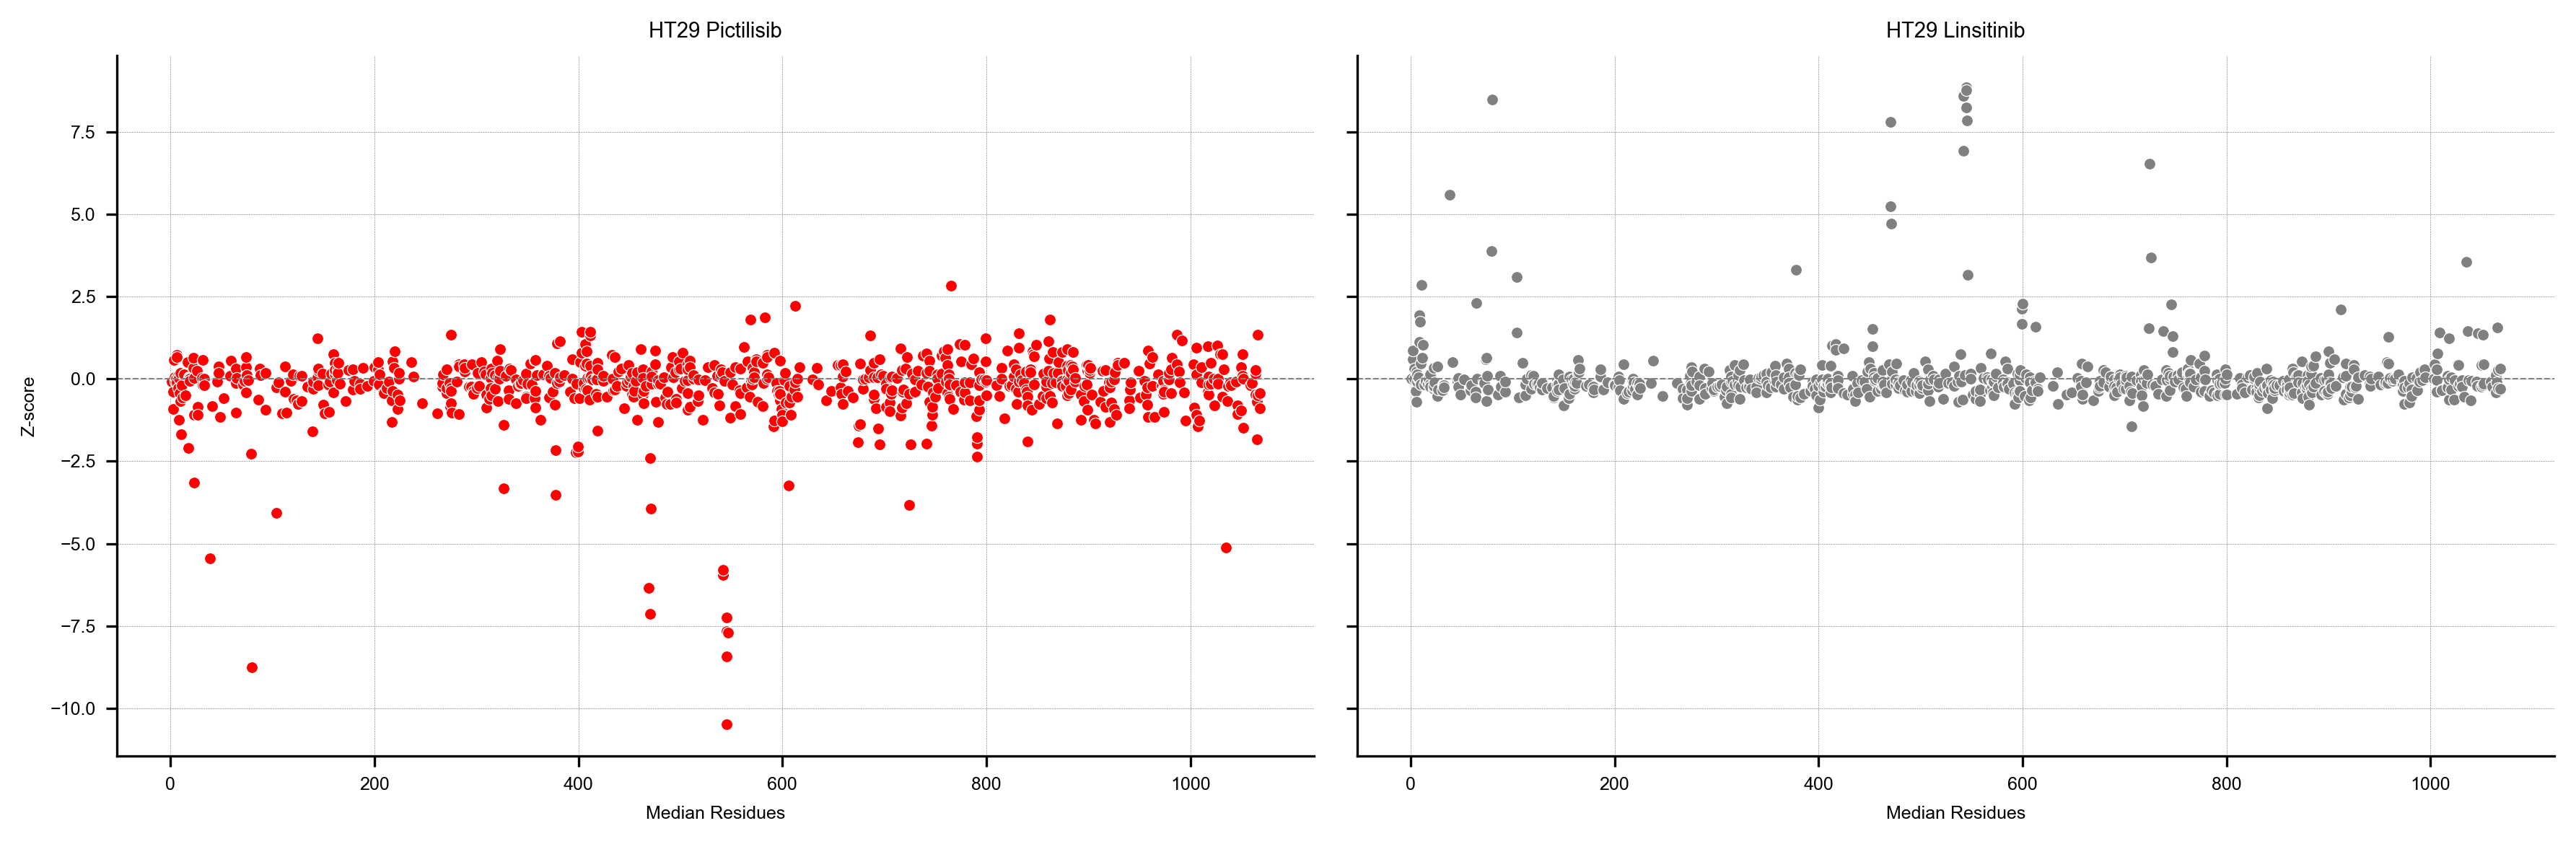

In [156]:
# Define conditions and z-score column names
conditions = ['Pictilisib', 'Linsitinib']
zscore_cols = {
    'Pictilisib': 'HT29_RDA270_CP2165_PIC_RepAB',
    'Linsitinib': 'HT29_RDA270_CP2165_LIN_RepAB',
}

# Set up subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Create scatter plots
for j, cond in enumerate(conditions):
    ax = axes[j]
    col = zscore_cols[cond]
    
    # Filter out NaNs
    plot_data = ht29_pik3ca_merged.dropna(subset=["Median Residues", col])
    
    sns.scatterplot(
        data=plot_data,
        x="Median Residues",
        y=col,
        color='red' if cond == "Pictilisib" else 'gray',
        ax=ax,
        s=15
    )
    ax.axhline(0, linestyle='--', color='gray', linewidth=0.5)
    ax.set_title(f"HT29 {cond}")
    ax.set_xlabel("Median Residues")
    if j == 0:
        ax.set_ylabel("Z-score")
    else:
        ax.set_ylabel("")

plt.tight_layout()
plt.show()

## HGSV Identifier

In [179]:
#Select the guides with strong context-specific effects 
guides_to_select=[
    'GCCTCACGGAGGCATTCTAA',
    'ATTCTTCCCTTTCTGCTTCT',
    'GAAACTCCATGCTTAGAGTT',
    'TGATTTCAGAGAGAGGATCT',
    'ATTTCAGAGAGAGGATCTCG',
    'GCTCAGTGATTTCAGAGAGA',
    'TGCTCAGTGATTTCAGAGAG',
    'CCTGCTCAGTGATTTCAGAG',
    'CTCCTGCTCAGTGATTTCAG'
]

ht29_pik3ca_selected_guides = ht29_pik3ca_merged[ht29_pik3ca_merged['sgRNA Sequence'].isin(guides_to_select)]

In [186]:
ht29_pik3ca_selected_guides

,Input,CRISPR Enzyme,Edit Type,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Symbol,Target Gene Strand,Target Transcript ID,Target Domain,sgRNA Sequence,sgRNA Context Sequence,PAM Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,Guide,Gene,Editor,HT29_RDA270_CP2165_PIC_RepA,HT29_RDA270_CP2165_PIC_RepB,HT29_RDA270_CP2165_SCH_RepA,HT29_RDA270_CP2165_SCH_RepB,HT29_RDA270_CP2165_LIN_RepA,HT29_RDA270_CP2165_LIN_RepB,HT29_RDA270_CP2165_PIC_RepAB,HT29_RDA270_CP2165_SCH_RepAB,HT29_RDA270_CP2165_LIN_RepAB,Residues,Median Residues,hgvs
53,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,GCCTCACGGAGGCATTCTAA,TGTAGCCTCACGGAGGCATTCTAAAGTCAC,AG,179198925,antisense,"179198938G>A, 179198940G>A","C_7, C_5","113G>A, 115G>A","Arg38His, Glu39Lys","Missense, Missense",NaN,NaN,GCCTCACGGAGGCATTCTAA,PIK3CA,CBE,-6.645601,-5.440541,0.282630,2.182565,5.595772,6.120460,-5.440541,0.282630,5.595772,38;39;,38.5,"[ENST00000263967.4:c.113G>A, ENST00000263967.4..."
92,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,ATTCTTCCCTTTCTGCTTCT,AAAAATTCTTCCCTTTCTGCTTCTTGAGTA,TG,179199050,antisense,"179199062G>A, 179199063G>A, 179199066G>A","C_8, C_7, C_4","237G>A, 238G>A, 241G>A","Arg79Arg, Glu80Lys, Glu81Lys","Silent, Missense, Missense",NaN,NaN,ATTCTTCCCTTTCTGCTTCT,PIK3CA,CBE,-8.757453,-9.076105,4.953969,5.331659,8.471428,8.624004,-8.757453,4.953969,8.471428,79;80;81;,80.0,"[ENST00000263967.4:c.237G>A, ENST00000263967.4..."
490,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,GAAACTCCATGCTTAGAGTT,TTAGGAAACTCCATGCTTAGAGTTGGAGTT,GG,179210431,sense,"179210435C>T, 179210437C>T;179210438C>T","C_5, C_7;C_8","1409C>T, 1411C>T;1412C>T","Thr470Ile, Pro471Leu","Missense, Missense",NaN,NaN,GAAACTCCATGCTTAGAGTT,PIK3CA,CBE,-7.769977,-7.141252,5.250946,6.005146,7.796857,8.021305,-7.141252,5.250946,7.796857,470;471;,470.5,"[ENST00000263967.4:c.1409C>T, ENST00000263967...."
571,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,TGATTTCAGAGAGAGGATCT,TCAGTGATTTCAGAGAGAGGATCTCGTGTA,CG,179218281,antisense,179218294G>A,C_7,1624G>A,Glu542Lys,Missense,NaN,NaN,TGATTTCAGAGAGAGGATCT,PIK3CA,CBE,-7.196775,-5.958042,7.088893,8.143457,8.585260,8.875831,-5.958042,7.088893,8.585260,542;,542.0,[ENST00000263967.4:c.1624G>A]
570,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,ATTTCAGAGAGAGGATCTCG,AGTGATTTCAGAGAGAGGATCTCGTGTAGA,TG,179218279,antisense,179218294G>A,C_5,1624G>A,Glu542Lys,Missense,NaN,NaN,ATTTCAGAGAGAGGATCTCG,PIK3CA,CBE,-5.805952,-5.880758,5.071845,5.391346,6.936577,7.543030,-5.805952,5.071845,6.936577,542;,542.0,[ENST00000263967.4:c.1624G>A]
574,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,GCTCAGTGATTTCAGAGAGA,TCCTGCTCAGTGATTTCAGAGAGAGGATCT,GG,179218287,antisense,179218303G>A,C_4,1633G>A,Glu545Lys,Missense,NaN,NaN,GCTCAGTGATTTCAGAGAGA,PIK3CA,CBE,-8.248787,-7.655505,7.589347,8.103960,8.849674,9.128919,-7.655505,7.589347,8.849674,545;,545.0,[ENST00000263967.4:c.1633G>A]
576,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,TGCTCAGTGATTTCAGAGAG,CTCCTGCTCAGTGATTTCAGAGAGAGGATC,AG,179218288,antisense,179218303G>A,C_5,1633G>A,Glu545Lys,Missense,NaN,NaN,TGCTCAGTGATTTCAGAGAG,PIK3CA,CBE,-8.483538,-7.237217,5.613951,7.018804,8.242384,8.409344,-7.237217,5.613951,8.242384,545;,545.0,[ENST00000263967.4:c.1633G>A]
578,ENST00000263967.4,SpyoCas9NG,C-T,4..8,9606,GRCh38,NC_000003.12,ENSG00000121879,PIK3CA,+,ENST00000263967.4,CDS,CCTGCTCAGTGATTTCAGAG,TTCTCCTGCTCAGTGATTTCAGAGAGAGGA,AG,179218290,antisense,179218303G

In [181]:
def beagle2vep(r: pd.Series) -> list[str]:
    """
    Create a list of ENSEMBL VEP HGVS notations from a row of the Beagle output.

    Args:
    r: pd.Series: A row of the Beagle output. Must contain the columns "Nucleotide Edits" and "Target Transcript ID".

    Returns:
    list[str]: A list of ENSEMBL VEP HGVS notations.

    """

    r_edits = r["Nucleotide Edits"].replace(",", ";").split(";")

    return [f"{r['Target Transcript ID']}:c.{v.strip()}" for v in r_edits]

In [185]:
ht29_pik3ca_selected_guides = ht29_pik3ca_selected_guides.copy()
ht29_pik3ca_selected_guides["hgvs"] = [
    "-" if r["Nucleotide Edits"] is np.nan else beagle2vep(r)
    for _, r in ht29_pik3ca_selected_guides.iterrows()
]

In [187]:
#Flatten the list of HGVS notations
variants_hgvs = [v for vs in ht29_pik3ca_selected_guides["hgvs"] if vs != "-" for v in vs]

In [189]:
#Write the HGVS notations to a file
with open("/Users/carolinapinto/desktop/Tese/Data/EG/EG-PIK3CA-HT29-HGVS.txt", "w") as f:
    for variant in variants_hgvs:
        f.write(f"{variant}\n")